Nombre: Felipe Aravena
Rut: 21.128.400-5
Fecha: 27-05


In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

In [2]:
#Ejercicio 1: Carga y exploración Inicial. 
#1.1
df = pd.read_csv('dataset_produccion_s13.csv')
print(df.head())

  id_lote      producto  turno  unidades_producidas  costo_unitario  \
0    L001  Abrazadera D  Tarde                  114            1.95   
1    L002     Válvula E  Tarde                  306            2.83   
2    L003      Tuerca C  Tarde                  180            3.66   
3    L004     Válvula E  Tarde                  210            2.14   
4    L005     Válvula E  Tarde                  336            4.87   

   temperatura_horno  tiempo_ciclo_min  defectos  costo_total  
0              204.4              37.8       8.0       222.30  
1              230.8              56.8      11.0       865.98  
2              242.8              44.8       4.0       658.80  
3              242.1              38.5       0.0       449.40  
4              234.6              14.9       9.0      1636.32  


In [3]:
#1.2
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_lote              60 non-null     str    
 1   producto             60 non-null     str    
 2   turno                60 non-null     str    
 3   unidades_producidas  60 non-null     int64  
 4   costo_unitario       59 non-null     float64
 5   temperatura_horno    59 non-null     float64
 6   tiempo_ciclo_min     60 non-null     float64
 7   defectos             59 non-null     float64
 8   costo_total          60 non-null     float64
dtypes: float64(5), int64(1), str(3)
memory usage: 4.3 KB
None
       unidades_producidas  costo_unitario  temperatura_horno  \
count            60.000000       59.000000          59.000000   
mean            244.266667        2.664576         229.406780   
std              90.248408        1.297236         104.204605   
min              84.000000        0.

In [4]:
#1.3
print(f"Valores nulos por columna\n {df.isnull().sum()}")

Valores nulos por columna
 id_lote                0
producto               0
turno                  0
unidades_producidas    0
costo_unitario         1
temperatura_horno      1
tiempo_ciclo_min       0
defectos               1
costo_total            0
dtype: int64


In [5]:
#1.4
def detectar_outliers(dataframe, columna):
    media = dataframe[columna].mean()
    desviacion = dataframe[columna].std()
    
    limite_inferior = media - (3 * desviacion)
    limite_superior = media + (3 * desviacion)
    
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    return outliers

outliers_temp = detectar_outliers(df, 'temperatura_horno')
outliers_tiempo = detectar_outliers(df, 'tiempo_ciclo_min')

print("Outlaiers temperatura del Horno")
display(outliers_temp[['id_lote', 'temperatura_horno']])

print("Outlaiers tiempo de ciclo minimo")
display(outliers_tiempo[['id_lote', 'tiempo_ciclo_min']])

Outlaiers temperatura del Horno


,id_lote,temperatura_horno
33,L034,999.9


Outlaiers tiempo de ciclo minimo


,id_lote,tiempo_ciclo_min


#1.5
Un valor en tiempo_ciclo_min es negativo. ¿Tiene sentido físico?

No tendria sentido un tiempo de ciclo negativo, ya que es imposible en el mundo real, un tiempo negativo debe indicar un error de digitación, falla en el sensor o corrupcion en la base de datos, segun el resumen estadístico, el valor mínimo registrado es -5, sin embargo, el filtro aplicado no lo detectó como outlier, ya que la alta desviación estándar empujó el límite matemático inferior hasta -10.19.

Costo verificado en 220°C: $1500.0


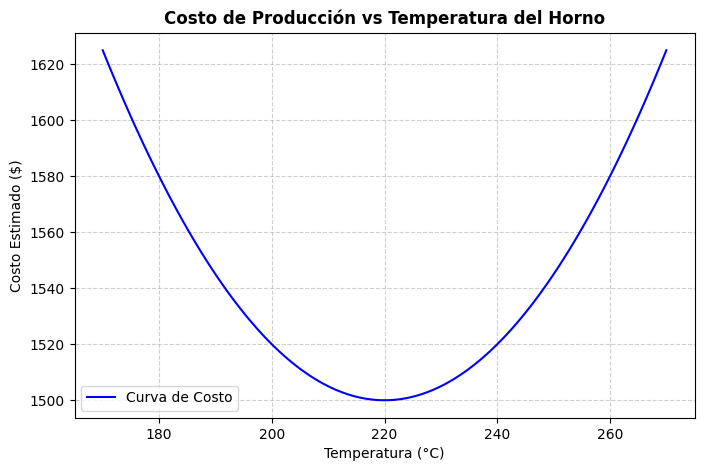

In [6]:
#Ejercicio 2: Optimización con scipy.optimize

def costo_produccion(temperatura):
    return 0.05 * (temperatura - 220)**2 + 1500
    
print(f"Costo verificado en 220°C: ${costo_produccion(220)}")


temperaturas = np.linspace(170, 270, 100)
costos = costo_produccion(temperaturas)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(temperaturas, costos, color='blue', label='Curva de Costo')
ax.set_title('Costo de Producción vs Temperatura del Horno', fontweight='bold')
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Costo Estimado ($)')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show()


Observa el gráfico: ¿es la función unimodal? ¿Tiene sentido aplicar minimize_scalar
directamente?

Sí, la función es unimodal (tiene un solo valle o mínimo global). Tiene todo el sentido usar minimize_scalar directamente, ya que no hay riesgo de caer en mínimos locales engañosos

In [7]:
#2.2
resultado_brent = minimize_scalar(costo_produccion, method='brent')

print("\nResultados metodo Brent")
if resultado_brent.success:
    print(f"Temperatura Óptima (x): {resultado_brent.x:.2f} °C")
    print(f"Costo Mínimo (fun): ${resultado_brent.fun:.2f}")
    print(f"Iteraciones (nit): {resultado_brent.nit}")
else:
    print("La optimización falló.")


Resultados metodo Brent
Temperatura Óptima (x): 220.00 °C
Costo Mínimo (fun): $1500.00
Iteraciones (nit): 4


¿la temperatura óptima hallada coincide con tu T_optima
definida? ¿Por qué o por qué no?

Sí, coincide exactamente con los 220 °C. Al ser una función cuadrática simple sin restricciones, el algoritmo matemático encuentra el vértice exacto sin problemas.

In [8]:
#2.3
resultado_bounded = minimize_scalar(costo_produccion, bounds=(180, 250), method='bounded')

print("\nResultados metodo Bounded")
if resultado_bounded.success:
    print(f"Temperatura Óptima (x): {resultado_bounded.x:.2f} °C")
    print(f"Costo Mínimo (fun): ${resultado_bounded.fun:.2f}")
    print(f"Iteraciones (nit): {resultado_bounded.nit}")
else:
    print("La optimización falló.")


Resultados metodo Bounded
Temperatura Óptima (x): 220.00 °C
Costo Mínimo (fun): $1500.00
Iteraciones (nit): 6


Compara resultado_brent.x con resultado_bounded.x. ¿Son iguales? ¿Cuál prefieres
y por qué?

Los resultados son idénticos (220 °C) porque el óptimo matemático justo cae dentro del rango seguro. Siempre es preferible usar bounded en ingeniería real para asegurar que la máquina no opere fuera de sus límites físicos.

Compara resultado_brent.nit con resultado_bounded.nit. ¿Cuál requiere más
iteraciones?

El método bounded requirió mayor iteraciones frente al metodo brent, debido a que realiza evaluaciones matemáticas obligatorias en los límites de seguridad antes de descender al óptimo.

In [9]:
#Ejercicio 3: Análisis Crítico e Interpretación
#3.1
comparacion = pd.DataFrame({  
    'Metodo': ['brent', 'bounded'],  
    'x_optimo': [resultado_brent.x, resultado_bounded.x],  
    'costo_min': [resultado_brent.fun, resultado_bounded.fun],  
    'iteraciones': [resultado_brent.nit, resultado_bounded.nit],  
    'convergio': [resultado_brent.success, resultado_bounded.success]  
}) 

print("Tabla resumen de optimizacion")
print(comparacion.to_string(index=False))

Tabla resumen de optimizacion
 Metodo  x_optimo  costo_min  iteraciones  convergio
  brent     220.0     1500.0            4       True
bounded     220.0     1500.0            6       True


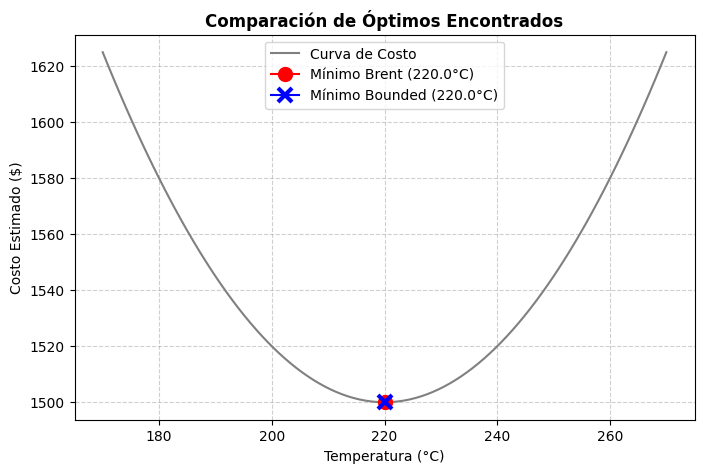

In [10]:
#3.2 
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(temperaturas, costos, color='grey', linestyle='-', label='Curva de Costo')

ax.plot(resultado_brent.x, resultado_brent.fun, marker='o', color='red', markersize=10, 
        label=f'Mínimo Brent ({resultado_brent.x:.1f}°C)')

ax.plot(resultado_bounded.x, resultado_bounded.fun, marker='x', color='blue', markersize=10, 
        markeredgewidth=3, label=f'Mínimo Bounded ({resultado_bounded.x:.1f}°C)')


ax.set_title('Comparación de Óptimos Encontrados', fontweight='bold')
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Costo Estimado ($)')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()

plt.show()

#Reflexion Final 

1.-¿Qué ventaja práctica ofrece el argumento bounds en un contexto industrial real?

Garantiza que el resultado se mantenga estrictamente dentro de los rangos operativos seguros de la maquinaria, previniendo recomendaciones algorítmicas que excedan las capacidades físicas del equipo y causen fallas catastróficas

2.-¿Qué ocurriría si definimos una función de costo con múltiples mínimos locales? ¿minimize_scalar sería suficiente?

El método minimize_scalar dejaría de ser confiable, ya que existe una alta probabilidad de que el algoritmo quede atrapado y converja en el primer mínimo local que encuentre en su descenso, ignorando el mínimo global de la función

3.-¿Cómo cambiarías la función de costo si el efecto de la temperatura fuera asimétrico?

Se reemplazaría la parábola estándar por una función definida por partes o se agregaría un término de penalización exponencial. Por ejemplo, si sobrecalentar es más grave que enfriar, la curva debe crecer mucho más abruptamente hacia la derecha de la temperatura óptima